# Drawtcha - Training Notebook

This notebook trains the machine learning models used in **Drawtcha**, a “draw-to-verify” CAPTCHA system inspired by Google reCAPTCHA and the Quick, Draw! game.

Instead of clicking images or solving text puzzles, the user is asked to **draw a simple object** (for example: *cat*, *tree*, or *house*). The system then analyzes the drawing to determine whether it was produced by a **human** or an **automated script**.

The full application, including the web interface and inference pipeline, is available in the official repository:
https://github.com/emanuellcs/drawtcha

---

## System Overview

Drawtcha combines **two complementary models**:

### 1) CNN Sketch Classifier

A **Convolutional Neural Network (CNN)** is trained on bitmap sketches to:

* Classify the final drawing into one of the target categories.
* Verify whether the user actually drew the requested object.

**Goal:**
Ensure the drawing content is semantically correct.

**Input:**
28×28 grayscale sketch image.

**Output:**
Category prediction (e.g., *cat*, *tree*, *car*).

### 2) Stroke Dynamics Model (RNN/LSTM)

A **Recurrent Neural Network (RNN)** is trained on the **temporal stroke data** to:

* Analyze drawing behavior over time.
* Detect patterns typical of automated or scripted drawings.

**Goal:**
Distinguish **human-like stroke dynamics** from bot-generated sequences.

**Input:**
Sequence of stroke deltas:

```
[dx, dy, pen_state]
```

**Output:**
Binary classification:

* Human-like drawing
* Automated drawing

---

## Dataset

This notebook uses the **Google Quick, Draw! dataset** (Tiny version) provided through Kaggle input.

The dataset contains:

* Millions of sketches across hundreds of categories.
* Both bitmap images and vector stroke sequences.

In this notebook:

* Bitmaps are used for CNN training.
* Stroke sequences are used for RNN training.

---

## Notebook Responsibilities

This notebook performs the following steps:

1. Load the Quick, Draw! dataset from Kaggle input.
2. Prepare bitmap data for CNN training.
3. Prepare stroke sequences for RNN training.
4. Train both models.
5. Evaluate validation performance.
6. Export trained model artifacts.

The exported models are then used by the Drawtcha application for real-time CAPTCHA verification.

---

## Output Artifacts

After training, the notebook produces:

* `cnn.onnx` - sketch classifier.
* `rnn.onnx` - stroke dynamics model.
* `config.json` - describes how the models were trained and how inputs must be interpreted.
* Optional zipped artifacts for deployment.

These files can be downloaded from the Kaggle output and placed into the application’s model directory.

---

## Integration with the Application

The trained models are consumed by the Drawtcha backend:

GitHub repository:
https://github.com/emanuellcs/drawtcha

The application:

1. Prompts the user to draw an object.
2. Sends the sketch and stroke data to the backend.
3. Runs both models.
4. Combines the results to decide whether the attempt is human.

---

## Expected Results

Typical validation performance:

* CNN accuracy: **94–97%**
* RNN human/bot accuracy: **95–99%** (depending on task setup)

---

## Notes

* This notebook is designed to run inside **Kaggle** with the dataset attached via the **Input** panel.
* No external downloads are required.
* All outputs are saved to `/kaggle/working`.

---

# Imports & Config

In [1]:
import os
import json
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

# Configuration
SEED = 42
rng = np.random.default_rng(SEED)

# Keep these labels small for a fast demo; expand as needed.
CLASSES = ['apple', 'door', 'star', 'fish', 'car', 'tree', 'eye', 'ladder']

MAX_SEQ_LEN = 100 # Max points/features for the RNN input (after preprocessing/padding)
IMG_SIZE = 28
SAMPLES_PER_CLASS = 2000

# Kaggle input (read-only)
DATASET_HINT = Path('/kaggle/input/datasets/organizations/google/tinyquickdraw')

# Kaggle working dir (writable) for outputs/artifacts
ARTIFACT_DIR = Path('/kaggle/working/artifacts')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Artifacts will be written to: {ARTIFACT_DIR}')

Using device: cpu
Artifacts will be written to: /kaggle/working/artifacts


# Input Dataset & Preprocessing Utilities

In [2]:
def resolve_dataset_root(hint: Path = DATASET_HINT) -> Path:
    """Resolve the attached dataset's root directory inside a Kaggle Notebook.

    Kaggle mounts attached datasets somewhere under /kaggle/input (read-only). If the user-provided
    hint path exists, we use it; otherwise we search one level under /kaggle/input for something
    that looks like the tinyquickdraw dataset.
    """
    hint = Path(hint)
    if hint.exists():
        return hint

    kaggle_input = Path('/kaggle/input')
    if not kaggle_input.exists():
        raise FileNotFoundError('Expected /kaggle/input to exist (Kaggle Notebook environment).')

    # Common mounts are /kaggle/input/<dataset-slug> or /kaggle/input/<org>/<dataset-slug>.
    candidates = []
    for child in kaggle_input.iterdir():
        if not child.is_dir():
            continue
        name = child.name.lower()
        if 'tinyquickdraw' in name or 'quickdraw' in name:
            candidates.append(child)

    # If no obvious candidates, fall back to scanning immediate subfolders
    if not candidates:
        for child in kaggle_input.iterdir():
            if child.is_dir():
                # Heuristic: dataset folders usually contain lots of ndjson/npy/npz
                has_qd_files = any(child.glob('**/*.ndjson')) or any(child.glob('**/*.npy')) or any(child.glob('**/*.npz'))
                if has_qd_files:
                    candidates.append(child)

    if not candidates:
        # Last resort: print what's in /kaggle/input to help debugging
        print('Could not auto-detect dataset root. /kaggle/input contains:')
        for p in kaggle_input.iterdir():
            print(' -', p)
        raise FileNotFoundError(f'Could not find dataset root. Hint not found: {hint}')

    # Prefer a candidate that actually contains quickdraw-ish files.
    for c in candidates:
        if any(c.glob('**/*.ndjson')) or any(c.glob('**/*.npy')) or any(c.glob('**/*.npz')):
            return c

    return candidates[0]


DATASET_ROOT = resolve_dataset_root()
print('Dataset root:', DATASET_ROOT)


def discover_class_files(dataset_root: Path, class_name: str) -> dict:
    """Find available files for a given class. Supports ndjson (strokes), npy (bitmaps), npz (sketch-rnn)."""
    cls = class_name.replace(' ', '_')
    patterns = {
        'ndjson': [
            f'**/{cls}.ndjson',
            f'**/{class_name}.ndjson',
        ],
        'npy': [
            f'**/{cls}.npy',
            f'**/full_numpy_bitmap_{cls}.npy',
            f'**/full_numpy_bitmap_{class_name}.npy',
        ],
        'npz': [
            f'**/{cls}.npz',
            f'**/{class_name}.npz',
        ],
    }

    found = {}
    for key, pats in patterns.items():
        matches = []
        for pat in pats:
            matches.extend(dataset_root.glob(pat))
        # De-dup
        matches = list(dict.fromkeys(matches))
        if matches:
            found[key] = matches[0]  # pick the first
    return found


FILES_BY_CLASS = {c: discover_class_files(DATASET_ROOT, c) for c in CLASSES}
for c, fm in FILES_BY_CLASS.items():
    print(f'{c}:', {k: str(v.relative_to(DATASET_ROOT)) for k, v in fm.items()})


def vector_to_raster(strokes, side=28, padding=16, bg_color=0, fg_color=255):
    """Convert stroke vectors (ndjson drawing format) to a 28x28 bitmap.

    Accepts the QuickDraw drawing format (list of strokes). Each stroke is typically:
        [[x0, x1, ...], [y0, y1, ...], [t0, t1, ...]]   (raw)
    or
        [[x0, x1, ...], [y0, y1, ...]]                 (simplified)
    This function ignores timestamps if present.
    """
    # Determine bounds
    min_x, max_x, min_y, max_y = 1e9, -1e9, 1e9, -1e9
    for stroke in strokes:
        if len(stroke) < 2:
            continue
        x_pts, y_pts = stroke[0], stroke[1]
        if len(x_pts) == 0:
            continue
        min_x = min(min_x, float(min(x_pts)))
        max_x = max(max_x, float(max(x_pts)))
        min_y = min(min_y, float(min(y_pts)))
        max_y = max(max_y, float(max(y_pts)))

    if not np.isfinite(min_x):
        return np.zeros((side, side), dtype=np.uint8)

    if max_x == min_x:
        max_x += 1.0
    if max_y == min_y:
        max_y += 1.0

    # Higher-res canvas for downsampling
    target_size = 256
    mask = np.zeros((target_size, target_size), dtype=np.uint8)

    orig_w = max_x - min_x
    orig_h = max_y - min_y
    scale = (target_size - 2 * padding) / max(orig_w, orig_h)

    for stroke in strokes:
        if len(stroke) < 2:
            continue
        x_pts, y_pts = stroke[0], stroke[1]
        if len(x_pts) < 2:
            continue

        pts = []
        for i in range(len(x_pts)):
            nx = int((x_pts[i] - min_x) * scale) + padding
            ny = int((y_pts[i] - min_y) * scale) + padding
            pts.append((nx, ny))

        for i in range(len(pts) - 1):
            cv2.line(mask, pts[i], pts[i + 1], fg_color, 4)

    return cv2.resize(mask, (side, side), interpolation=cv2.INTER_AREA)


def preprocess_strokes_rnn_ndjson(raw_drawing, max_len=MAX_SEQ_LEN):
    """Convert ndjson strokes to a fixed-length [dx, dy, pen_lift] sequence."""
    strokes = []
    for stroke in raw_drawing:
        if len(stroke) < 2:
            continue
        x, y = stroke[0], stroke[1]
        pts = np.stack((x, y), axis=1).astype(np.float32)
        strokes.append(pts)

    seq = []
    for s_idx, stroke in enumerate(strokes):
        for i in range(len(stroke)):
            if i == 0:
                dx, dy = 0.0, 0.0
                pen_lift = 1.0 if s_idx > 0 else 0.0
            else:
                dx = stroke[i, 0] - stroke[i - 1, 0]
                dy = stroke[i, 1] - stroke[i - 1, 1]
                pen_lift = 0.0
            seq.append([dx, dy, pen_lift])

    if not seq:
        seq = np.zeros((0, 3), dtype=np.float32)
    else:
        seq = np.asarray(seq, dtype=np.float32)

    # Normalize deltas (avoid div-by-zero)
    if len(seq) > 0:
        std = float(np.std(seq[:, :2])) + 1e-6
        seq[:, :2] /= std

    # Pad/truncate
    if len(seq) > max_len:
        seq = seq[:max_len]
    else:
        seq = np.pad(seq, ((0, max_len - len(seq)), (0, 0)), mode='constant', constant_values=0.0)

    return seq


def preprocess_strokes_rnn_npz(stroke_seq, max_len=MAX_SEQ_LEN):
    """Convert sketch-rnn stroke sequences into fixed-length [dx, dy, pen_lift].

    Quick, Draw! is commonly distributed in multiple formats:

    - **ndjson**: strokes as lists of absolute x/y point coordinates (and sometimes timestamps).
    - **sketch-rnn npz**: sequences in *delta* form. Two common encodings:
        * stroke-3:  [dx, dy, pen_state]  (pen_state often signals stroke boundaries)
        * stroke-5:  [dx, dy, p1, p2, p3] where p2 is "pen up" and p3 is "end of drawing"

    This helper maps both into our model's 3-feature input:
        [dx, dy, pen_lift]
    where pen_lift=1 indicates a stroke boundary.
    """
    seq = np.asarray(stroke_seq)

    if seq.ndim != 2 or seq.shape[1] < 2:
        seq = np.zeros((0, 3), dtype=np.float32)
    else:
        seq = seq.astype(np.float32)
        dx = seq[:, 0]
        dy = seq[:, 1]

        if seq.shape[1] >= 5:
            # stroke-5: [dx, dy, p1, p2, p3]  -> use p2 as pen_lift
            pen_lift = seq[:, 3]
        elif seq.shape[1] >= 3:
            # stroke-3: interpret 3rd column as a stroke-boundary-ish indicator
            pen_lift = (seq[:, 2] > 0).astype(np.float32)
        else:
            pen_lift = np.zeros_like(dx, dtype=np.float32)

        seq = np.stack([dx, dy, pen_lift], axis=1).astype(np.float32)

    # Normalize deltas
    if len(seq) > 0:
        std = float(np.std(seq[:, :2])) + 1e-6
        seq[:, :2] /= std

    # Pad/truncate
    if len(seq) > max_len:
        seq = seq[:max_len]
    else:
        seq = np.pad(seq, ((0, max_len - len(seq)), (0, 0)), mode='constant', constant_values=0.0)

    return seq


def load_bitmaps_from_npy(npy_path: Path, n_samples: int, seed: int = SEED) -> np.ndarray:
    """Load N bitmap samples from a QuickDraw .npy bitmap file (memory-mapped)."""
    arr = np.load(npy_path, mmap_mode='r')
    # Common formats: (N, 784) or (N, 28, 28)
    if arr.ndim == 2 and arr.shape[1] == IMG_SIZE * IMG_SIZE:
        arr = arr.reshape(-1, IMG_SIZE, IMG_SIZE)
    elif arr.ndim == 3 and arr.shape[1:] == (IMG_SIZE, IMG_SIZE):
        pass
    else:
        raise ValueError(f'Unexpected .npy shape {arr.shape} for {npy_path}')

    total = arr.shape[0]
    take = min(n_samples, total)
    local_rng = np.random.default_rng(seed)
    idx = local_rng.choice(total, size=take, replace=False) if take < total else np.arange(total)
    # Make a copy (mmap slices can be non-contiguous)
    return np.asarray(arr[idx], dtype=np.uint8)


def iter_ndjson_drawings(ndjson_path: Path):
    """Yield (drawing, recognized) from an ndjson file."""
    with ndjson_path.open('r') as f:
        for line in f:
            item = json.loads(line)
            yield item.get('drawing', []), bool(item.get('recognized', True))


Dataset root: /kaggle/input/datasets/organizations/google/tinyquickdraw
apple: {'ndjson': 'quickdraw_simplified/apple.ndjson', 'npz': 'sketches/sketches/apple.npz'}
door: {'ndjson': 'quickdraw_simplified/door.ndjson', 'npz': 'sketches/sketches/door.npz'}
star: {'ndjson': 'quickdraw_simplified/star.ndjson', 'npz': 'sketches/sketches/star.npz'}
fish: {'ndjson': 'quickdraw_simplified/fish.ndjson', 'npz': 'sketches/sketches/fish.npz'}
car: {'ndjson': 'quickdraw_simplified/car.ndjson', 'npz': 'sketches/sketches/car.npz'}
tree: {'ndjson': 'quickdraw_simplified/tree.ndjson', 'npz': 'sketches/sketches/tree.npz'}
eye: {'ndjson': 'quickdraw_simplified/eye.ndjson', 'npz': 'sketches/sketches/eye.npz'}
ladder: {'ndjson': 'quickdraw_simplified/ladder.ndjson', 'npz': 'sketches/sketches/ladder.npz'}


# Dataset Loading & Augmentation

Loading and processing data...
Loaded class=apple | CNN=2000 | RNN drawings=2000
Loaded class=door | CNN=2000 | RNN drawings=2000
Loaded class=star | CNN=2000 | RNN drawings=2000
Loaded class=fish | CNN=2000 | RNN drawings=2000
Loaded class=car | CNN=2000 | RNN drawings=2000
Loaded class=tree | CNN=2000 | RNN drawings=2000
Loaded class=eye | CNN=2000 | RNN drawings=2000
Loaded class=ladder | CNN=2000 | RNN drawings=2000
Total CNN samples: 16000
Total RNN samples: 32000


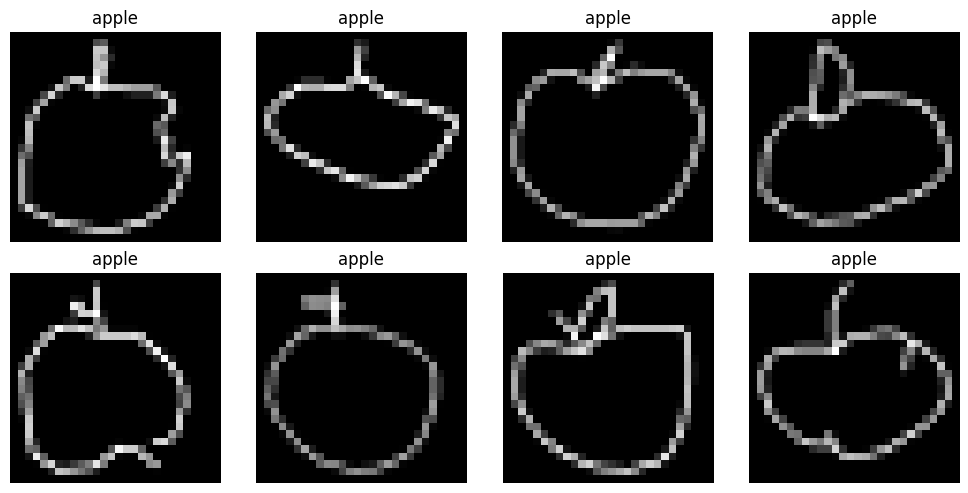

In [3]:
def load_dataset_subset(files_by_class: dict, samples_per_class: int, seed: int = SEED):
    """Create (CNN) bitmap samples and (RNN) sequence samples for the configured CLASSES.

    CNN:
      - Prefer .npy 28x28 bitmap files if present (fast).
      - Fallback: rasterize from ndjson strokes.

    RNN:
      - Prefer .npz sketch-rnn style sequences if present.
      - Fallback: build sequences from ndjson strokes.
    """
    data_cnn = []  # (img[1,28,28], label_idx)
    data_rnn = []  # (seq[MAX_SEQ_LEN,3], is_human)

    labels_map = {name: i for i, name in enumerate(CLASSES)}
    local_rng = np.random.default_rng(seed)

    for class_name in CLASSES:
        fmeta = files_by_class.get(class_name, {})
        label_idx = labels_map[class_name]

        # CNN data
        if 'npy' in fmeta:
            bitmaps = load_bitmaps_from_npy(fmeta['npy'], samples_per_class, seed=seed + label_idx)
            for img in bitmaps:
                data_cnn.append((img[np.newaxis, :, :], label_idx))
        elif 'ndjson' in fmeta:
            ndjson_path = fmeta['ndjson']
            taken = 0
            for drawing, recognized in iter_ndjson_drawings(ndjson_path):
                if not recognized:
                    continue
                img = vector_to_raster(drawing, IMG_SIZE)
                data_cnn.append((img[np.newaxis, :, :], label_idx))
                taken += 1
                if taken >= samples_per_class:
                    break
        else:
            raise FileNotFoundError(
                f'No bitmap source found for class={class_name}. Expected .npy or .ndjson under {DATASET_ROOT}'
            )

        # RNN data (human vs synthetic)
        # We create 1 human + 1 synthetic sample per drawing.
        seq_taken = 0
        if 'npz' in fmeta:
            # QuickDraw sketch-rnn .npz often stores arrays under keys like train/valid/test
            # and may require allow_pickle/latin1 for object arrays.
            npz = np.load(fmeta['npz'], allow_pickle=True, encoding='latin1')
            # Prefer 'train' if present, else any first key
            key = 'train' if 'train' in npz.files else npz.files[0]
            strokes = npz[key]
            total = len(strokes)
            take = min(samples_per_class, total)
            idx = local_rng.choice(total, size=take, replace=False) if take < total else np.arange(total)

            for j in idx:
                seq_human = preprocess_strokes_rnn_npz(strokes[j])
                data_rnn.append((seq_human, 1.0))

                seq_bot = seq_human.copy()
                seq_bot[:, 0] = seq_bot[:, 0] * 1.5  # simple synthetic artifact
                data_rnn.append((seq_bot, 0.0))

            seq_taken = take

        elif 'ndjson' in fmeta:
            ndjson_path = fmeta['ndjson']
            for drawing, recognized in iter_ndjson_drawings(ndjson_path):
                if not recognized:
                    continue
                seq_human = preprocess_strokes_rnn_ndjson(drawing)
                data_rnn.append((seq_human, 1.0))

                seq_bot = seq_human.copy()
                seq_bot[:, 0] = seq_bot[:, 0] * 1.5
                data_rnn.append((seq_bot, 0.0))

                seq_taken += 1
                if seq_taken >= samples_per_class:
                    break

        else:
            # No stroke source found -> skip RNN for this class
            pass

        print(f'Loaded class={class_name} | CNN={samples_per_class} | RNN drawings={seq_taken}')

    return data_cnn, data_rnn


print('Loading and processing data...')
raw_cnn, raw_rnn = load_dataset_subset(FILES_BY_CLASS, SAMPLES_PER_CLASS)
print(f'Total CNN samples: {len(raw_cnn)}')
print(f'Total RNN samples: {len(raw_rnn)}')

# Quick sanity check: show a few images
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, (img, lbl) in zip(axes.flatten(), raw_cnn[:8]):
    ax.imshow(img[0], cmap='gray')
    ax.set_title(CLASSES[lbl])
    ax.axis('off')
plt.tight_layout()
plt.show()

# Models Definition

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 14x14
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class LivenessRNN(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64, num_layers=2):
        super(LivenessRNN, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=False)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (batch, seq, features)
        out, (hn, cn) = self.lstm(x)
        # Take last hidden state
        out = out[:, -1, :]
        return self.fc(out)

# Training Loop

In [5]:
# Datasets
class CNNDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self): 
        return len(self.data)
    def __getitem__(self, idx):
        img, label = self.data[idx]
        return torch.tensor(img, dtype=torch.float32) / 255.0, torch.tensor(label, dtype=torch.long)

class RNNDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self): 
        return len(self.data)
    def __getitem__(self, idx):
        seq, label = self.data[idx]
        return torch.tensor(seq, dtype=torch.float32), torch.tensor(label, dtype=torch.float32).unsqueeze(0)

# Split CNN
cnn_train, cnn_val = train_test_split(raw_cnn, test_size=0.2, random_state=SEED, shuffle=True)

cnn_loader = DataLoader(CNNDataset(cnn_train), batch_size=64, shuffle=True, num_workers=2)
cnn_val_loader = DataLoader(CNNDataset(cnn_val), batch_size=64, shuffle=False, num_workers=2)

# Train CNN
cnn_model = SimpleCNN(len(CLASSES)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

print('Training CNN...')
for epoch in range(10):
    cnn_model.train()
    total_loss = 0.0
    for imgs, labels in cnn_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn_model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item())

    # Quick val accuracy
    cnn_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in cnn_val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = cnn_model(imgs).argmax(dim=1)
            correct += int((preds == labels).sum().item())
            total += int(labels.numel())
    acc = correct / max(1, total)

    print(f'Epoch {epoch+1} | loss={total_loss/len(cnn_loader):.4f} | val_acc={acc:.4f}')

# Train RNN
train_rnn = len(raw_rnn) > 0
if train_rnn:
    rnn_train, rnn_val = train_test_split(raw_rnn, test_size=0.2, random_state=SEED, shuffle=True)
    rnn_loader = DataLoader(RNNDataset(rnn_train), batch_size=64, shuffle=True, num_workers=2)
    rnn_val_loader = DataLoader(RNNDataset(rnn_val), batch_size=64, shuffle=False, num_workers=2)

    rnn_model = LivenessRNN().to(device)
    criterion_rnn = nn.BCELoss()
    optimizer_rnn = optim.Adam(rnn_model.parameters(), lr=1e-3)

    def last_valid_timestep(out, lengths):
        """
        Out: (B, T, H) from LSTM
        Lengths: (B,) lengths in [1..T]
        Returns: (B, H) output at last valid timestep for each element
        """
        # Lengths are 1-based; convert to 0-based indices
        idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, out.size(2)) # (B,1,H)
        return out.gather(dim=1, index=idx).squeeze(1) # (B,H)

    print('Training RNN...')
    for epoch in range(10):
        rnn_model.train()
        total_loss = 0.0

        for seqs, labels in rnn_loader:
            seqs = seqs.to(device) # (B,T,3)
            labels = labels.to(device) # (B,1)

            # Infer non-pad lengths from right-padded zeros
            # Pad rows are exactly [0,0,0] in our preprocessing
            nonpad = (seqs.abs().sum(dim=2) != 0) # (B,T) bool
            lengths = nonpad.long().sum(dim=1) # (B,)
            lengths = lengths.clamp(min=1, max=seqs.size(1))

            optimizer_rnn.zero_grad()

            # Bypass rnn_model.forward() so we don't use out[:, -1, :] (padded tail)
            out, _ = rnn_model.lstm(seqs) # out: (B,T,H)
            last = last_valid_timestep(out, lengths) # (B,H)
            probs = rnn_model.fc(last) # (B,1), already Sigmoid()

            loss = criterion_rnn(probs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(rnn_model.parameters(), 1.0)
            optimizer_rnn.step()

            total_loss += float(loss.item())

        # Validation
        rnn_model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for seqs, labels in rnn_val_loader:
                seqs = seqs.to(device)
                labels = labels.to(device)

                nonpad = (seqs.abs().sum(dim=2) != 0)
                lengths = nonpad.long().sum(dim=1).clamp(min=1, max=seqs.size(1))

                out, _ = rnn_model.lstm(seqs)
                last = last_valid_timestep(out, lengths)
                probs = rnn_model.fc(last)

                preds = (probs >= 0.5).float()
                correct += int((preds == labels).sum().item())
                total += int(labels.numel())

        acc = correct / max(1, total)
        print(f'Epoch {epoch+1} | loss={total_loss/len(rnn_loader):.4f} | val_acc={acc:.4f}')
else:
    rnn_model = None
    print('No stroke files (.ndjson/.npz) were detected for the selected classes -> skipping RNN training.')

Training CNN...
Epoch 1 | loss=0.7333 | val_acc=0.8728
Epoch 2 | loss=0.3074 | val_acc=0.9216
Epoch 3 | loss=0.2025 | val_acc=0.9353
Epoch 4 | loss=0.1426 | val_acc=0.9519
Epoch 5 | loss=0.1168 | val_acc=0.9534
Epoch 6 | loss=0.0916 | val_acc=0.9534
Epoch 7 | loss=0.0762 | val_acc=0.9578
Epoch 8 | loss=0.0630 | val_acc=0.9606
Epoch 9 | loss=0.0475 | val_acc=0.9603
Epoch 10 | loss=0.0409 | val_acc=0.9531
Training RNN...
Epoch 1 | loss=0.4263 | val_acc=0.9500
Epoch 2 | loss=0.2158 | val_acc=0.9111
Epoch 3 | loss=0.1869 | val_acc=0.9445
Epoch 4 | loss=0.1919 | val_acc=0.9364
Epoch 5 | loss=0.1623 | val_acc=0.9597
Epoch 6 | loss=0.1018 | val_acc=0.9880
Epoch 7 | loss=0.1141 | val_acc=0.9853
Epoch 8 | loss=0.0832 | val_acc=0.9916
Epoch 9 | loss=0.0663 | val_acc=0.9922
Epoch 10 | loss=0.0652 | val_acc=0.9902


# Export Artifacts

In [6]:
# Export CNN to ONNX
dummy_input_cnn = torch.randn(1, 1, 28, 28, device=device)
torch.onnx.export(
    cnn_model, dummy_input_cnn, str(ARTIFACT_DIR / 'cnn.onnx'),
    input_names=['input'], output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    opset_version=17
)

# Export RNN to ONNX
if rnn_model is not None:
    dummy_input_rnn = torch.randn(1, MAX_SEQ_LEN, 3, device=device)
    torch.onnx.export(
        rnn_model, dummy_input_rnn, str(ARTIFACT_DIR / 'rnn.onnx'),
        input_names=['input'], output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
        opset_version=17
    )

# Export Config
config = {
    'classes': CLASSES,
    'img_size': IMG_SIZE,
    'max_seq_len': MAX_SEQ_LEN,
    'rnn_features': ['dx', 'dy', 'pen_lift'],
    'dataset_root': str(DATASET_ROOT),
    'files_by_class': {k: {kk: str(vv) for kk, vv in fm.items()} for k, fm in FILES_BY_CLASS.items()},
}
with open(ARTIFACT_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Artifacts exported successfully to:', ARTIFACT_DIR)

# Create Zip
zip_name = 'drawtcha_artifacts.zip'
!zip -r {zip_name} {ARTIFACT_DIR}

/tmp/ipykernel_17/3329274253.py:3: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


Artifacts exported successfully to: /kaggle/working/artifacts
  adding: kaggle/working/artifacts/ (stored 0%)
  adding: kaggle/working/artifacts/config.json (deflated 85%)
  adding: kaggle/working/artifacts/rnn.onnx (deflated 9%)
  adding: kaggle/working/artifacts/cnn.onnx (deflated 7%)


/tmp/ipykernel_17/3329274253.py:13: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/torch/onnx/symbolic_opset9.py:4244: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the mo